# Modelagem — Churn Bancário

## Objetivo
Treinar e comparar modelos de Machine Learning para prever churn,
selecionando o melhor baseado em métricas adequadas para dados desbalanceados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


## 1. Carregando Dados Processados

In [2]:
df = pd.read_csv('../data/processed/train_processed.csv')

# Separando features (X) do alvo (y)
X = df.drop(columns=['Exited'])
y = df['Exited']

print(f"Shape do dataset: {df.shape}")
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"\nDistribuição do alvo:")
print(y.value_counts())

Shape do dataset: (165034, 17)
Shape de X: (165034, 16)
Shape de y: (165034,)

Distribuição do alvo:
Exited
0    130113
1     34921
Name: count, dtype: int64


## 2. Dividindo em Treino e Teste

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% para teste
    random_state=42,    # garante reprodutibilidade
    stratify=y          # mantém proporção de churn nos dois conjuntos
)

print(f"Treino: {X_train.shape[0]:,} registros")
print(f"Teste:  {X_test.shape[0]:,} registros")
print(f"\nProporção de churn no treino: {y_train.mean()*100:.1f}%")
print(f"Proporção de churn no teste:  {y_test.mean()*100:.1f}%")

Treino: 132,027 registros
Teste:  33,007 registros

Proporção de churn no treino: 21.2%
Proporção de churn no teste:  21.2%


## 3. Modelo 1 — Regressão Logística (Baseline)

In [4]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== REGRESSÃO LOGÍSTICA ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== REGRESSÃO LOGÍSTICA ===
AUC-ROC: 0.8152

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90     26023
           1       0.70      0.38      0.49      6984

    accuracy                           0.83     33007
   macro avg       0.77      0.67      0.69     33007
weighted avg       0.82      0.83      0.81     33007



## 4. Modelo 2 — Random Forest

In [5]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # trata o desbalanceamento!
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
AUC-ROC: 0.8700

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     26023
           1       0.73      0.52      0.61      6984

    accuracy                           0.86     33007
   macro avg       0.80      0.73      0.76     33007
weighted avg       0.85      0.86      0.85     33007



## 5. Modelo 3 — XGBoost

In [6]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,  # equivalente ao class_weight no XGBoost
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBOOST ===")
print(f"Scale pos weight usado: {scale_pos_weight:.2f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

=== XGBOOST ===
Scale pos weight usado: 3.73
AUC-ROC: 0.8847

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88     26023
           1       0.55      0.77      0.64      6984

    accuracy                           0.82     33007
   macro avg       0.74      0.80      0.76     33007
weighted avg       0.85      0.82      0.83     33007



## 6. Comparação dos Modelos

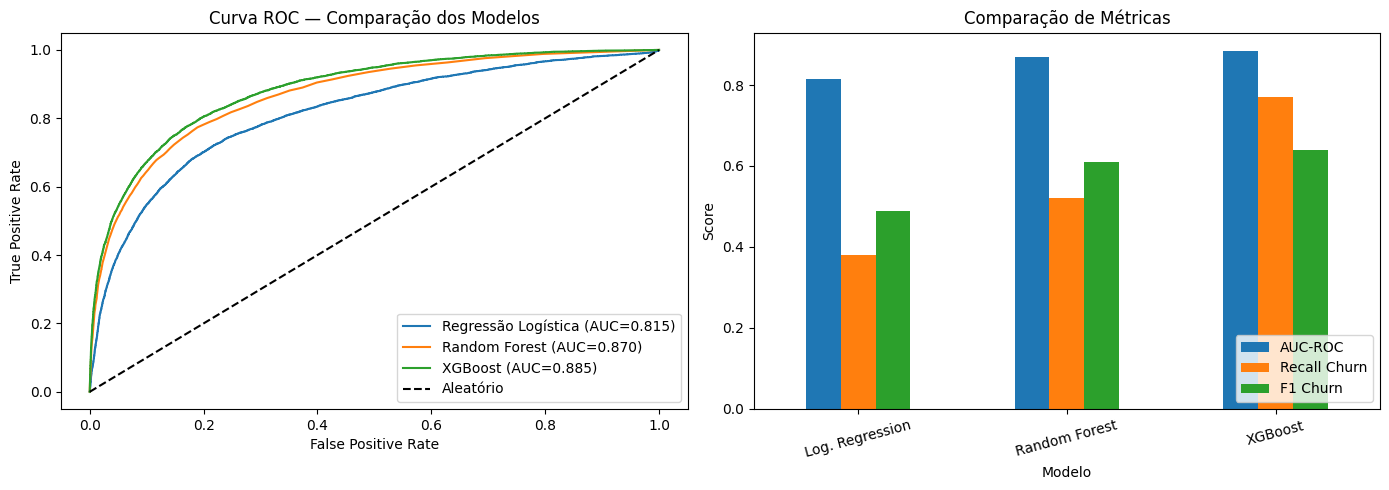

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
models = {
    'Regressão Logística': y_prob_lr,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb
}

for name, prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0,1], [0,1], 'k--', label='Aleatório')
axes[0].set_title('Curva ROC — Comparação dos Modelos')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Comparação de métricas
metrics = {
    'Modelo': ['Log. Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [0.8152, 0.8700, 0.8847],
    'Recall Churn': [0.38, 0.52, 0.77],
    'F1 Churn': [0.49, 0.61, 0.64]
}
df_metrics = pd.DataFrame(metrics).set_index('Modelo')

df_metrics.plot(kind='bar', ax=axes[1], rot=15)
axes[1].set_title('Comparação de Métricas')
axes[1].set_ylabel('Score')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 7. Salvando o Modelo Final

In [8]:
# Salva o modelo XGBoost
joblib.dump(xgb, '../models/xgb_model.pkl')

print("Modelo XGBoost salvo em: models/xgb_model.pkl")
print("\nArquivos salvos:")
print("  - models/xgb_model.pkl  (modelo)")
print("  - models/scaler.pkl     (scaler)")

Modelo XGBoost salvo em: models/xgb_model.pkl

Arquivos salvos:
  - models/xgb_model.pkl  (modelo)
  - models/scaler.pkl     (scaler)


## 8. Explicabilidade com SHAP

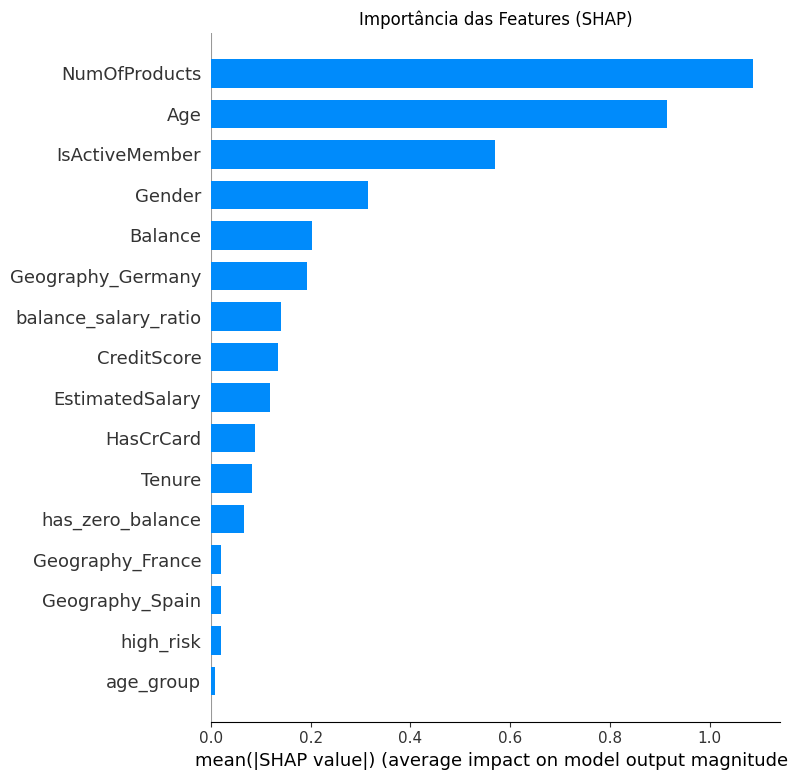

In [9]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Importância das Features (SHAP)')
plt.tight_layout()
plt.show()